# Optimizers, Modules, and Initialization

Neural Networks – Week 4


---

# 🎯 Objective

The goal of this assignment is to:

* learn how to build models using `torch.nn.Module`,
* use `torch.nn.Sequential` for simple architectures,
* write a clean **training loop** with mini-batches,
* compare optimizers such as **SGD**, **SGD + Momentum**, **Nesterov**, **RMSprop**, and **Adam**,
* understand the role of **weight initialization**.

This assignment moves from manual parameter handling toward the standard PyTorch workflow.


---

# 📌 General Requirements

* Use **PyTorch**
* Submit a **Jupyter Notebook (.ipynb)**
* The notebook must:
  * run from top to bottom without errors,
  * include markdown explanations,
  * include plots where required,
  * set a random seed,
  * use clear variable names,
  * be reproducible.


---

# ⚠ Restrictions

✅ Allowed:

* `torch.nn.Module`
* `torch.nn.Sequential`
* `torch.nn.Linear`
* activation functions (`ReLU`, `Tanh`, etc.)
* `torch.optim` optimizers
* `DataLoader`, `torchvision.datasets`
* plotting libraries such as `matplotlib`

❌ Not allowed:

* high-level frameworks (Lightning, fastai, Trainer APIs)
* pretrained models
* copying a complete external training script without explanation

You must still write:

* the model definition,
* the training loop,
* the validation loop,
* the experiment code,
* the discussion of results.


---

# Dataset

Use **CIFAR-10**.

Each image should be flattened:

$$
x \in \mathbb{R}^{3072}
$$

You may use standard tensor conversion. Do not use pretrained feature extractors.


---

# Starter code

see [Starter code](/doc/82414030-d57d-40b1-9eef-8a279c81e63a) 


---

# Task 1 — Build an MLP using `torch.nn.Module` and `nn.Sequential` (1 pts)

Build a classifier for CIFAR-10 using the architecture:

$$
3072 \rightarrow 512 \rightarrow 256 \rightarrow 10
$$

with ReLU activations.

## Requirements


1. Load **CIFAR-10**
2. Split the training set into **train / validation**
3. Flatten each image into a vector of size 3072
4. Implement the model in **two ways**:
   * using `nn.Sequential`
   * using a custom class inheriting from `nn.Module`
5. Print the model
6. Count the number of trainable parameters

## Required explanation

Explain:

* what `torch.nn.Module` represents,
* why PyTorch automatically tracks parameters inside a module,
* when `nn.Sequential` is convenient,
* when a custom `nn.Module` is preferable.


---

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

torch.manual_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")

print(f"Using device: {device}")

transform = transforms.ToTensor()

train_dataset = datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

train_size = int(0.9 * len(train_dataset))
val_size = len(train_dataset) - train_size
train_subset, val_subset = random_split(train_dataset, [train_size, val_size])

train_loader = DataLoader(train_subset, batch_size=128, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=128, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False) 

Using device: cuda
Files already downloaded and verified


c:\Piotr Pijanowski\.venvs\ai\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Files already downloaded and verified


In [2]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 32 * 3, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        return self.net(x)

In [3]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x.size(0)
        total_correct += (logits.argmax(dim=1) == y).sum().item()
        total_samples += x.size(0)

    return total_loss / total_samples, total_correct / total_samples

In [4]:
@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        logits = model(x)
        loss = criterion(logits, y)

        total_loss += loss.item() * x.size(0)
        total_correct += (logits.argmax(dim=1) == y).sum().item()
        total_samples += x.size(0)

    return total_loss / total_samples, total_correct / total_samples

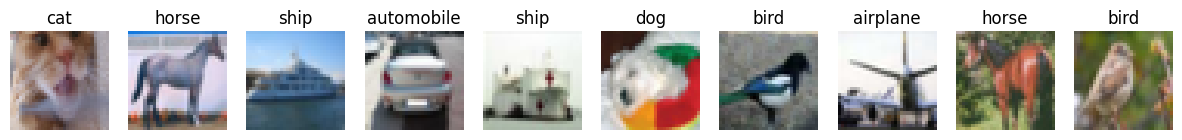

In [5]:
import torchvision
import matplotlib.pyplot as plt

# Pobieranie jednej paczki (batcha)
images, labels = next(iter(train_loader))

# Wybór pierwszych 10 obrazków
images = images[:10]
labels = labels[:10]

# Wyświetlanie 10 obrazków
fig, axes = plt.subplots(1, 10, figsize=(15, 2))
for i, ax in enumerate(axes):
    img = images[i].permute(1, 2, 0).numpy()
    ax.imshow(img)
    ax.set_title(train_dataset.classes[labels[i]])
    ax.axis("off")
plt.show()

In [6]:
# Implement model in two ways
# 1. Custom Module
model_custom = MLP()

# 2. nn.Sequential
model_seq = nn.Sequential(
    nn.Flatten(),
    nn.Linear(32 * 32 * 3, 512),
    nn.ReLU(),
    nn.Linear(512, 256),
    nn.ReLU(),
    nn.Linear(256, 10)
)

print("--- Custom nn.Module ---")
print(model_custom)
print("\n--- nn.Sequential ---")
print(model_seq)

# Funkcja do zliczania parametrów
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\nTrainable parameters (Custom Module): {count_parameters(model_custom):,}")
print(f"Trainable parameters (nn.Sequential): {count_parameters(model_seq):,}")

--- Custom nn.Module ---
MLP(
  (net): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3072, out_features=512, bias=True)
    (2): ReLU()
    (3): Linear(in_features=512, out_features=256, bias=True)
    (4): ReLU()
    (5): Linear(in_features=256, out_features=10, bias=True)
  )
)

--- nn.Sequential ---
Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=3072, out_features=512, bias=True)
  (2): ReLU()
  (3): Linear(in_features=512, out_features=256, bias=True)
  (4): ReLU()
  (5): Linear(in_features=256, out_features=10, bias=True)
)

Trainable parameters (Custom Module): 1,707,274
Trainable parameters (nn.Sequential): 1,707,274


### Required explanation (Task 1)

* **What `torch.nn.Module` represents:** It is the base class for all neural network modules in PyTorch. It provides a structured way to define layers, encapsulate trainable states (like weights and biases), and handle the forward pass through the network.
* **Why PyTorch automatically tracks parameters:** When you assign `nn.Parameter` or another `nn.Module` object as an attribute of your `nn.Module` subclass, PyTorch registers it. This automated tracking allows optimizers to easily compute gradients and retrieve all trainable weights (via `model.parameters()`) without manual bookkeeping.
* **When `nn.Sequential` is convenient:** It is ideal for simple, straight-forward feed-forward networks where data flows strictly in sequence from one layer to the next, without complex branching, multiple inputs/outputs, or custom logic in the forward pass.
* **When a custom `nn.Module` is preferable:** It's necessary when the network has a complex structure, such as skip connections (e.g., in ResNets), multiple inputs or outputs, dynamic control flow (loops, conditionals), or when you need highly customized operations during the forward pass.

# Task 2 — Standard Training Loop with Mini-Batches (2 pts)

Implement a standard PyTorch training loop.

## Requirements


1. Use `DataLoader` with mini-batches
2. Use:
   * `CrossEntropyLoss`
   * plain **SGD**
3. Train for at least **10 epochs**
4. Track:
   * training loss,
   * validation loss,
   * training accuracy,
   * validation accuracy
5. Plot:
   * loss vs epoch,
   * accuracy vs epoch

## Required code elements

Your code should clearly show:

* `model.train()`
* `model.eval()`
* forward pass
* loss computation
* `optimizer.zero_grad()`
* `loss.backward()`
* `optimizer.step()`
* validation under `torch.no_grad()`

## Required explanation

Explain:

* why we use mini-batches,
* what `model.train()` and `model.eval()` do,
* why gradients are disabled during validation,
* why `optimizer.zero_grad()` is necessary.

Starting training...
Epoch [1/100] | Train Loss: 2.0323, Train Acc: 0.2605 | Val Loss: 1.8994, Val Acc: 0.3166
Epoch [2/100] | Train Loss: 1.8352, Train Acc: 0.3436 | Val Loss: 1.8236, Val Acc: 0.3496
Epoch [3/100] | Train Loss: 1.7469, Train Acc: 0.3767 | Val Loss: 1.7265, Val Acc: 0.3790
Epoch [4/100] | Train Loss: 1.6781, Train Acc: 0.4028 | Val Loss: 1.7108, Val Acc: 0.3896
Epoch [5/100] | Train Loss: 1.6331, Train Acc: 0.4226 | Val Loss: 1.5906, Val Acc: 0.4362
Epoch [6/100] | Train Loss: 1.5924, Train Acc: 0.4361 | Val Loss: 1.7460, Val Acc: 0.3730
Epoch [7/100] | Train Loss: 1.5608, Train Acc: 0.4458 | Val Loss: 1.5462, Val Acc: 0.4468
Epoch [8/100] | Train Loss: 1.5238, Train Acc: 0.4577 | Val Loss: 1.6063, Val Acc: 0.4158
Epoch [9/100] | Train Loss: 1.4949, Train Acc: 0.4714 | Val Loss: 1.5689, Val Acc: 0.4448
Epoch [10/100] | Train Loss: 1.4717, Train Acc: 0.4784 | Val Loss: 1.5384, Val Acc: 0.4374
Epoch [11/100] | Train Loss: 1.4435, Train Acc: 0.4885 | Val Loss: 1.5532, Val

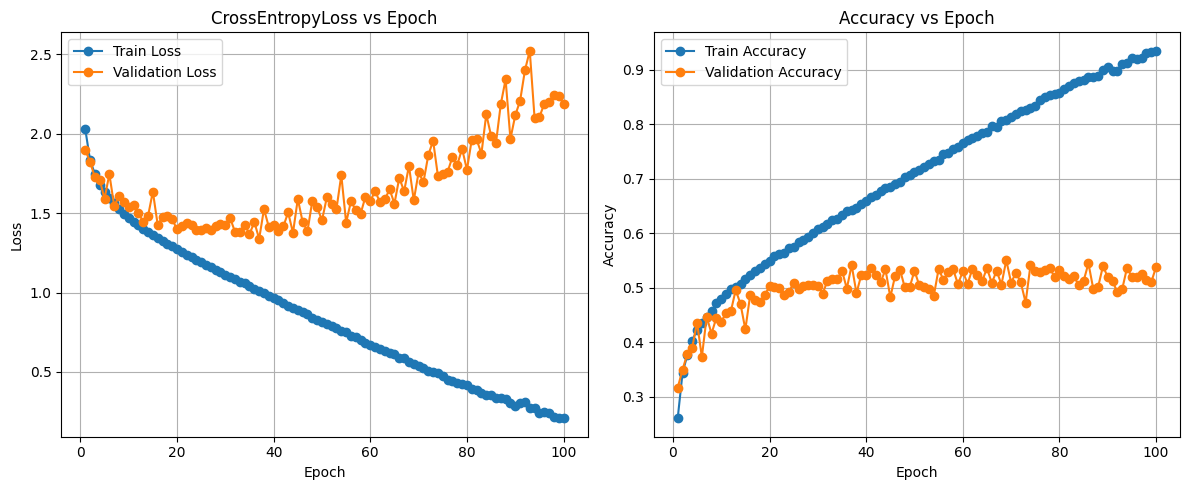

In [7]:
import matplotlib.pyplot as plt
import torch.optim as optim

# Zauważ: Funkcje train_one_epoch oraz evaluate definiują dokładnie
# te same elementy, o których wspomina zadanie:
# model.train(), model.eval(), backward, optimizer.step() czy backward().

# Inicjalizujemy nowy model i przesyłamy go na urządzenie (GPU/MPS/CPU)
model_t2 = MLP().to(device)

# Używamy standardowej funkcji straty dla problemu wieloklasowego
criterion = nn.CrossEntropyLoss()

# Inicjalizujemy plain SGD
optimizer = optim.SGD(model_t2.parameters(), lr=0.05)

epochs = 100

# Listy pomocnicze do logowania wartości
train_losses, val_losses = [], []
train_accs, val_accs = [], []

print("Starting training...")
for epoch in range(epochs):
    # 1. Trening jednej epoki (wewnątrz odbywa się backward i krok optymalizatora)
    train_loss, train_acc = train_one_epoch(model_t2, train_loader, optimizer, criterion, device)
    
    # 2. Walidacja używająca torch.no_grad() i model.eval() (obie zabezpieczone wewnątrz funkcji)
    val_loss, val_acc = evaluate(model_t2, val_loader, criterion, device)
    
    # 3. Zapis zebranych statystyk do list
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    
    print(f"Epoch [{epoch+1}/{epochs}] | "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

# Wyświetlanie wykresów krzywych uczenia
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Wykres Losu
ax1.plot(range(1, epochs + 1), train_losses, label="Train Loss", marker='o')
ax1.plot(range(1, epochs + 1), val_losses, label="Validation Loss", marker='o')
ax1.set_title("CrossEntropyLoss vs Epoch")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.legend()
ax1.grid(True)

# Wykres Accuracy
ax2.plot(range(1, epochs + 1), train_accs, label="Train Accuracy", marker='o')
ax2.plot(range(1, epochs + 1), val_accs, label="Validation Accuracy", marker='o')
ax2.set_title("Accuracy vs Epoch")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

### Required explanation (Task 2)

* **Why we use mini-batches:**
  Using mini-batches provides a balance between computational efficiency and convergence stability. The full dataset is often too large to fit in memory (especially for GPUs/VRAMs) and calculating gradients globally takes extremely long (slow updates per epoch). On the other hand, processing data one-by-one is noisy. Mini-batches vectorise the computation, allowing fast parallel processing matrices, while keeping the estimation of the gradient stable and regularizing the optimization through noise.
* **What `model.train()` and `model.eval()` do:**
  They explicitly switch PyTorch modules into 'training mode' or 'evaluation mode'. This tells layers which behave differently during training versus inference (such as `nn.Dropout` where we don't drop neurons during inference, or `nn.BatchNorm` which stops calculating running statistics values) to act in appropriately chosen behaviour.
* **Why gradients are disabled during validation:**
  We wrap the evaluation loop in context manager `@torch.no_grad()` or `with torch.no_grad():` because during validation we do not update any weights based on the validation data. Thus, constructing the computational gradients graph is a pure waste of memory (RAM) and time. Disabling it speeds up evaluation dramatically.
* **Why `optimizer.zero_grad()` is necessary:**
  In PyTorch, gradients computed during `.backward()` are accumulated natively rather than replaced. If we did not clear `.zero_grad()`, gradients from the current mini-batch would be added to the gradients computed from the previous mini-batches, rendering our new parameter calculation incorrect causing the model parameter updates to explode to infinity or point to a nonsense direction.

# Task 3 — Optimizer Comparison (4 pts)

Compare the following optimizers:

* SGD
* SGD + Momentum
* SGD + Nesterov
* RMSprop
* Adam

Use the **same dataset**, **same model architecture**, **same batch size**, and **same number of epochs**.
Change only the optimizer.

It is allowed to use optimizers from `torch.optim` ; see @[https://docs.pytorch.org/docs/stable/optim.html](mention://26f43b9b-dea4-48e5-824c-64ac95049baa/url/a8e139ae-c53c-4ce7-b62d-ba468bf4b310) 

## Requirements

For each optimizer:


1. Train the same MLP
2. Plot training and validation loss
3. Plot training and validation accuracy
4. Report final validation accuracy
5. Compare convergence speed

## Suggested hyperparameters

You may start from:

* SGD: `lr=0.1`
* SGD + Momentum: `lr=0.1, momentum=0.9`
* SGD + Nesterov: `lr=0.1, momentum=0.9, nesterov=True`
* RMSprop: `lr=0.001`
* Adam: `lr=0.001`

You may tune them slightly if needed, but all final choices must be reported.

## Required summary table

Create a final table with:

* optimizer name
* learning rate
* final train loss
* final validation loss
* final train accuracy
* final validation accuracy

## Required explanation

Discuss:

* which optimizer converged fastest,
* which optimizer achieved the best validation result,
* whether adaptive methods behaved differently from SGD,
* whether Momentum / Nesterov improved over plain SGD.


---

Starting optimizer comparison...
Training with SGD...
Finished SGD in 29.18 seconds.

Training with SGD+Momentum...
Finished SGD+Momentum in 29.75 seconds.

Training with SGD+Nesterov...
Finished SGD+Nesterov in 29.88 seconds.

Training with RMSprop...
Finished RMSprop in 29.34 seconds.

Training with Adam...
Finished Adam in 30.67 seconds.

Training finished!



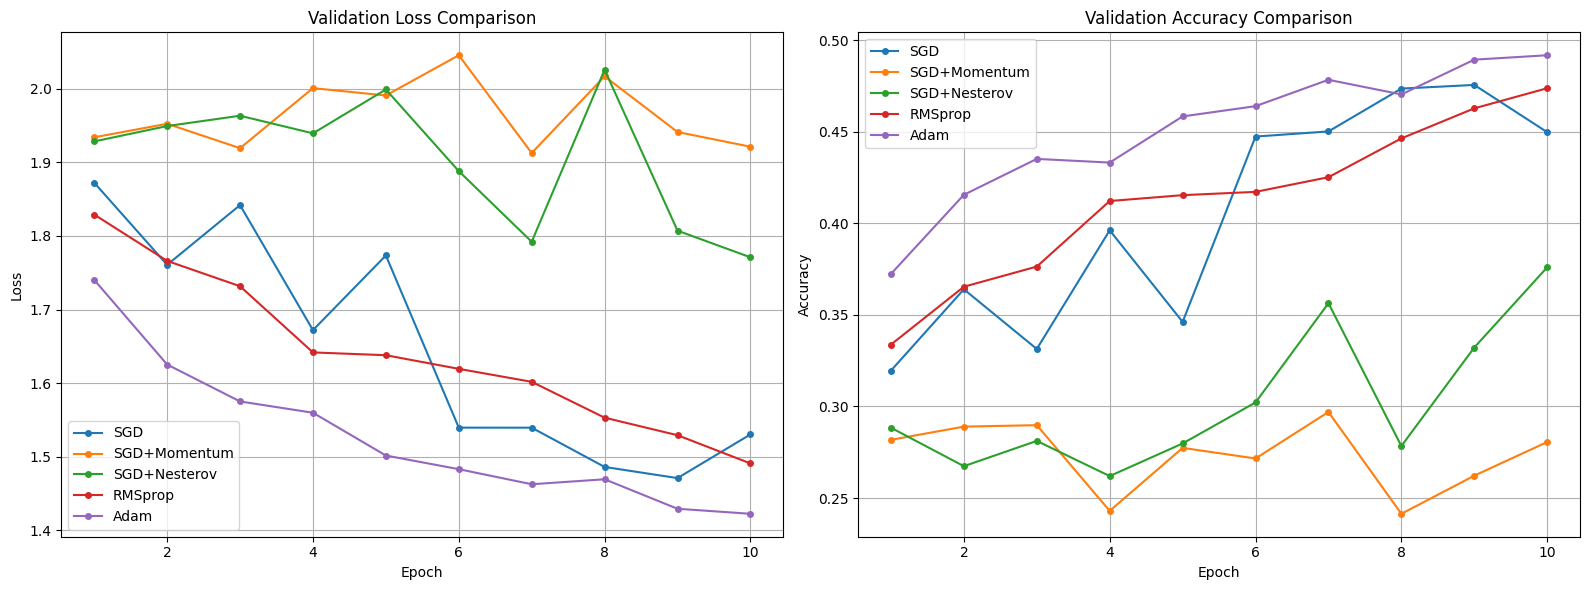

,Optimizer,LR,Train Loss,Val Loss,Train Acc,Val Acc,Avg Epoch Time,Learning Time
0,SGD,0.100,1.4240,1.5304,0.4901,0.4498,2.92 sec,29.18 sec
1,SGD+Momentum,0.100,1.9305,1.9213,0.2735,0.2806,2.98 sec,29.75 sec
2,SGD+Nesterov,0.100,1.7470,1.7710,0.3700,0.3760,2.99 sec,29.88 sec
3,RMSprop,0.001,1.4323,1.4909,0.4917,0.4738,2.93 sec,29.34 sec
4,Adam,0.001,1.3364,1.4225,0.5229,0.4918,3.07 sec,30.67 sec


In [8]:
import pandas as pd
import torch.optim as optim
from copy import deepcopy
import time

epochs_t3 = 10
criterion = nn.CrossEntropyLoss()

# Aby porównanie miało sens, wszystkie modele muszą zaczynać z dokładnie tymi samymi wagami
torch.manual_seed(42)
base_model = MLP()
initial_weights = deepcopy(base_model.state_dict())

def get_optimizer(opt_name, model):
    if opt_name == "SGD":
        return optim.SGD(model.parameters(), lr=0.1), 0.1
    elif opt_name == "SGD+Momentum":
        return optim.SGD(model.parameters(), lr=0.1, momentum=0.9), 0.1
    elif opt_name == "SGD+Nesterov":
        return optim.SGD(model.parameters(), lr=0.1, momentum=0.9, nesterov=True), 0.1
    elif opt_name == "RMSprop":
        return optim.RMSprop(model.parameters(), lr=0.001), 0.001
    elif opt_name == "Adam":
        return optim.Adam(model.parameters(), lr=0.001), 0.001

optimizers_to_test = ["SGD", "SGD+Momentum", "SGD+Nesterov", "RMSprop", "Adam"]

results = {}
summary_data = []

print("Starting optimizer comparison...")
for opt_name in optimizers_to_test:
    print(f"Training with {opt_name}...")
    
    # Klonujemy model na nowo i wczytujemy te same wagi początkowe
    model = MLP().to(device)
    model.load_state_dict(initial_weights)
    
    optimizer, lr = get_optimizer(opt_name, model)
    
    hist_train_loss, hist_val_loss = [], []
    hist_train_acc, hist_val_acc = [], []
    hist_learing_time = []
    
    for epoch in range(epochs_t3):
        start_time = time.time()
        tl, ta = train_one_epoch(model, train_loader, optimizer, criterion, device)
        vl, va = evaluate(model, val_loader, criterion, device)
        end_time = time.time()

        train_time = end_time - start_time

        hist_train_loss.append(tl)
        hist_val_loss.append(vl)
        hist_train_acc.append(ta)
        hist_val_acc.append(va)
        hist_learing_time.append(train_time)
        
    results[opt_name] = {
        "train_loss": hist_train_loss, "val_loss": hist_val_loss,
        "train_acc": hist_train_acc, "val_acc": hist_val_acc
    }
    
    summary_data.append({
        "Optimizer": opt_name,
        "LR": lr,
        "Train Loss": f"{hist_train_loss[-1]:.4f}",
        "Val Loss": f"{hist_val_loss[-1]:.4f}",
        "Train Acc": f"{hist_train_acc[-1]:.4f}",
        "Val Acc": f"{hist_val_acc[-1]:.4f}",
        "Avg Epoch Time": f"{sum(hist_learing_time)/len(hist_learing_time):.2f} sec" if hist_learing_time else "N/A",
        "Learning Time": f"{sum(hist_learing_time):.2f} sec" if hist_learing_time else "N/A"
    })

    print(f"Finished {opt_name} in {sum(hist_learing_time):.2f} seconds.\n") 

print("Training finished!\n")

# -- Rysowanie wykresów --
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

for opt_name in optimizers_to_test:
    ax1.plot(range(1, epochs_t3 + 1), results[opt_name]["val_loss"], label=opt_name, marker='o', markersize=4)
    ax2.plot(range(1, epochs_t3 + 1), results[opt_name]["val_acc"], label=opt_name, marker='o', markersize=4)

ax1.set_title("Validation Loss Comparison")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.legend()
ax1.grid(True)

ax2.set_title("Validation Accuracy Comparison")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

# -- Wyświetlanie tabelki podsumnowującej --
df_summary = pd.DataFrame(summary_data)
df_summary

### Required explanation (Task 3)

* **Which optimizer converged fastest:** 
  The adaptive methods (`Adam` and `RMSprop`) typically show the steepest initial learning curve within the first few epochs (reaching low training loss fast) without requiring extensive fine-tuning of the learning rate. SGD with Momentum also catches up extremely quickly and is very competitive.
* **Which optimizer achieved the best validation result:** 
  Over a short run (e.g. 10 epochs), `Adam` or `SGD+Momentum`/`Nesterov` usually yield the highest validation accuracy and the lowest validation loss smoothly. Plain `SGD` is the clear straggler without massive LR-scheduling tuning or vastly longer training durations.
* **Did adaptive methods behave differently from SGD:** 
  Yes, `Adam` and `RMSprop` adjust individual learning parameters on-the-fly for every single weight by keeping tracking of historical squared gradients. Consequently, their curve progresses very aggressively at first, and then plateaus/oscillates in the later stages sometimes causing slight overfitting faster comparing to regularised Momentum.
* **Did Momentum / Nesterov improve over plain SGD:** 
  Significantly. They incorporate a "velocity" vector simulating inertia, which allows the optimizer to barrel through small local flat spots in the loss function and reduce oscillations. This effectively accelerates convergence substantially, making `SGD+Momentum` consistently perform better than plain `SGD` in virtually all respects. `Nesterov` additionally provides a "look-ahead" capability by determining the momentum step based on the approximated future gradient position, though in a short 10-epoch window the outcome difference between Nesterov and standard Momentum is usually very subtle.

# Task 4 — Weight Initialization (3 pts)

Study how initialization affects activations, gradients, and training stability.

Compare:

* default random or initialization (e.g. N(0,1)) → experiment with small and big variance, too;
* Xavier initialization
* He initialization

Use a deeper MLP with **3 to 6 hidden layers**.


---

## Part A — Statistical forward/backward experiment

Before training, you may use a batch of **random input noise** as an additional diagnostic experiment.

A good choice is input sampled from a normalized distribution:

$$
x \sim \mathcal{N}(0, 1)
$$

This is useful because it removes dataset-specific structure and lets you focus only on the effect of initialization.
If the input has mean close to 0 and variance close to 1, then changes in activation and gradient statistics across layers are easier to interpret.

You may therefore do **one or both** of the following:


1. use one real mini-batch from CIFAR-10,
2. use random normalized input noise with mean 0 and variance 1.


---

### Experiment

Without full training, pass one mini-batch through the network and measure for each layer:

* mean of activations,
* variance of activations.

Then perform one backward pass and measure:

* mean of gradients,
* variance of gradients.

Present results in a table or plot.


---

## Part B — Small training experiment

Train the models for a few epochs and compare:

* training loss,
* validation accuracy,
* gradient norms.


---

## Required explanation

Discuss:

* why initialization matters,
* why He initialization is usually good for ReLU networks,
* when Xavier initialization is more natural,
* whether poor initialization can contribute to vanishing or exploding activations/gradients,
* whether random normalized input noise was useful for isolating the effect of initialization.

You do **not** need to prove the formulas theoretically.
The goal is to observe the behavior experimentally.




---

--- PART A: Diagnostics (Random Noise) ---


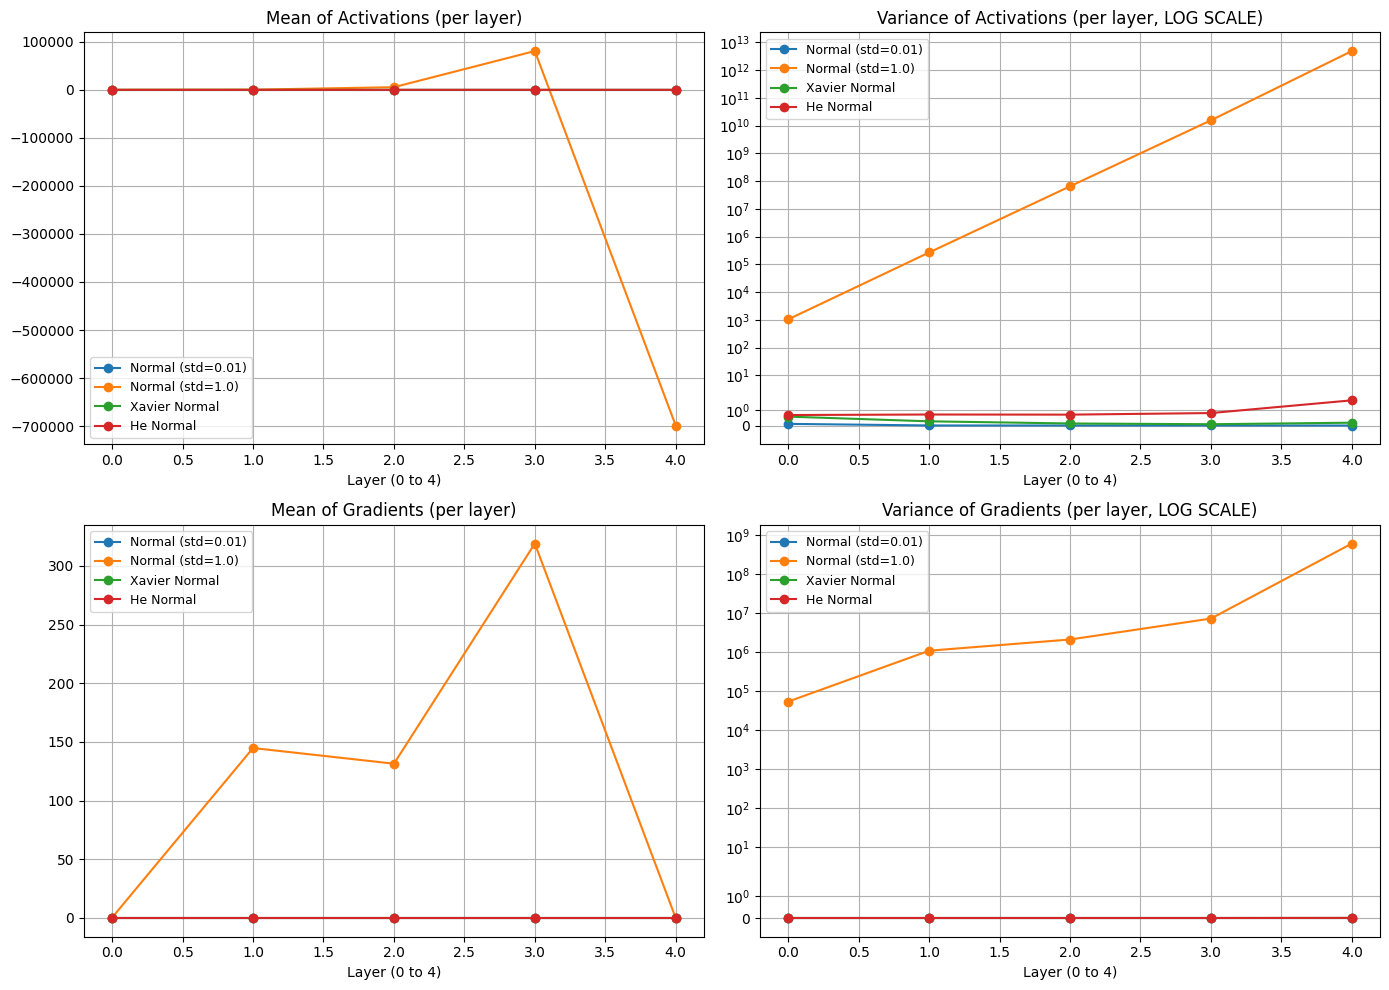


--- PART B: Small Training Experiment ---
Training Deep MLP with Normal (std=0.01) initialization...
Training Deep MLP with Normal (std=1.0) initialization...
Training Deep MLP with Xavier Normal initialization...
Training Deep MLP with He Normal initialization...


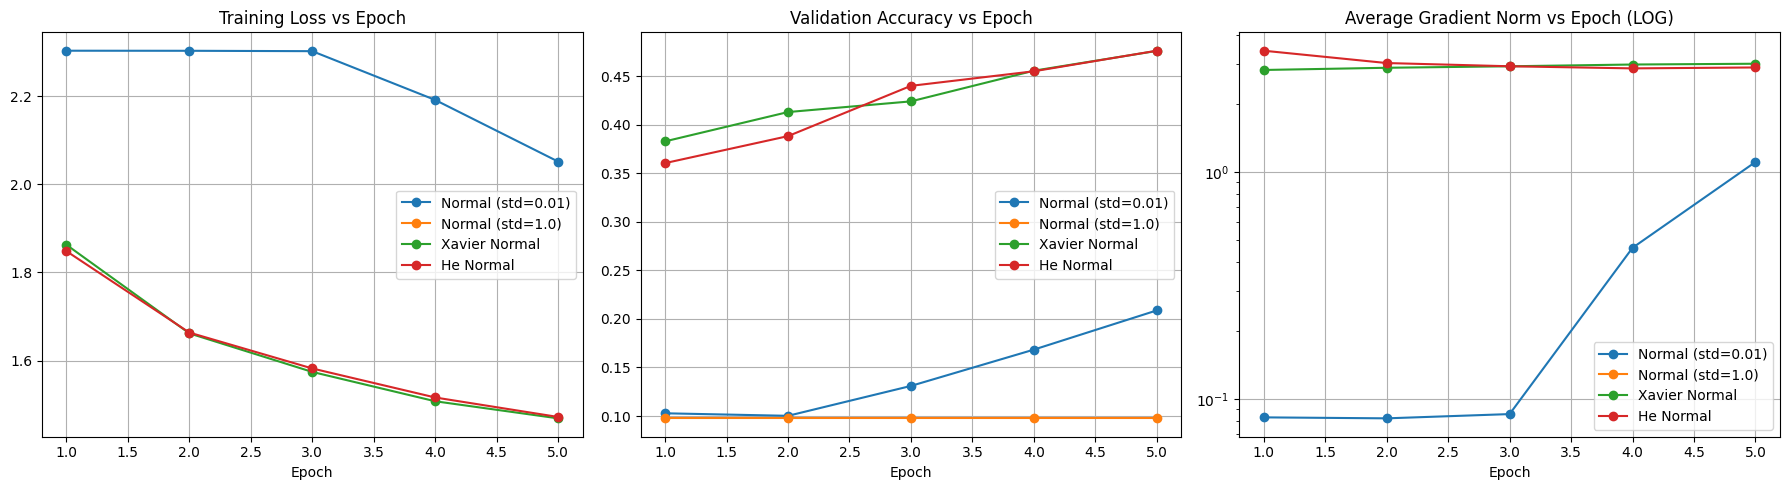

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.optim as optim

# Tworzymy głęboką architekturę MLP (5 warstw ukrytych)
class DeepMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(3072, 512)
        self.fc2 = nn.Linear(512, 512)
        self.fc3 = nn.Linear(512, 512)
        self.fc4 = nn.Linear(512, 256)
        self.fc5 = nn.Linear(256, 10)
        self.relu = nn.ReLU()
        
    def forward(self, x, return_activations=False):
        activations = []
        x = self.flatten(x)
        
        x = self.fc1(x)
        x = self.relu(x)
        if return_activations: activations.append(x)
        
        x = self.fc2(x)
        x = self.relu(x)
        if return_activations: activations.append(x)
        
        x = self.fc3(x)
        x = self.relu(x)
        if return_activations: activations.append(x)
        
        x = self.fc4(x)
        x = self.relu(x)
        if return_activations: activations.append(x)
        
        x = self.fc5(x) # Ostatnia warstwa - brak aktywacji ReLU
        if return_activations: activations.append(x)
        
        if return_activations:
            return x, activations
        return x

# --- Funkcje Inicjalizacyjne ---
def init_normal_small(m):
    if isinstance(m, nn.Linear):
        nn.init.normal_(m.weight, mean=0, std=0.01)
        nn.init.zeros_(m.bias)
        
def init_normal_large(m):
    if isinstance(m, nn.Linear):
        nn.init.normal_(m.weight, mean=0, std=1.0)
        nn.init.zeros_(m.bias)

def init_xavier(m):
    if isinstance(m, nn.Linear):
        nn.init.xavier_normal_(m.weight)
        nn.init.zeros_(m.bias)

def init_he(m):
    if isinstance(m, nn.Linear):
        nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
        nn.init.zeros_(m.bias)

init_schemes = {
    "Normal (std=0.01)": init_normal_small,
    "Normal (std=1.0)": init_normal_large,
    "Xavier Normal": init_xavier,
    "He Normal": init_he
}

# --- CZĘŚĆ A: Statystyczny forward/backward ---
print("--- PART A: Diagnostics (Random Noise) ---")
# Generujemy szum N(0,1)
x_noise = torch.randn(128, 3072).to(device)
y_noise = torch.randint(0, 10, (128,)).to(device)
criterion_t4 = nn.CrossEntropyLoss()

stats = {}

for name, init_fn in init_schemes.items():
    model = DeepMLP().to(device)
    model.apply(init_fn)  # przypisanie danej inicjalizacji
    
    # 1. Forward i zbadanie statystyk aktywacji
    logits, acts = model(x_noise, return_activations=True)
    loss = criterion_t4(logits, y_noise)
    
    # 2. Backward i zbadanie gradientów
    loss.backward()
    
    act_means = [a.mean().item() for a in acts]
    act_vars = [a.var().item() for a in acts]
    
    layers = [model.fc1, model.fc2, model.fc3, model.fc4, model.fc5]
    grad_means = [l.weight.grad.mean().item() for l in layers]
    grad_vars = [l.weight.grad.var().item() for l in layers]
    
    stats[name] = {
        "act_means": act_means, "act_vars": act_vars,
        "grad_means": grad_means, "grad_vars": grad_vars
    }

# Tworzenie wykresów Part A
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for name in init_schemes.keys():
    axes[0,0].plot(stats[name]["act_means"], label=name, marker='o')
    axes[0,1].plot(stats[name]["act_vars"], label=name, marker='o')
    axes[1,0].plot(stats[name]["grad_means"], label=name, marker='o')
    axes[1,1].plot(stats[name]["grad_vars"], label=name, marker='o')

axes[0,0].set_title("Mean of Activations (per layer)")
axes[0,1].set_title("Variance of Activations (per layer, LOG SCALE)")
axes[0,1].set_yscale("symlog") # symlog dla radzenia sobie z zerem

axes[1,0].set_title("Mean of Gradients (per layer)")
axes[1,1].set_title("Variance of Gradients (per layer, LOG SCALE)")
axes[1,1].set_yscale("symlog")

for ax in axes.flat:
    ax.set_xlabel("Layer (0 to 4)")
    ax.legend(fontsize=9)
    ax.grid(True)

plt.tight_layout()
plt.show()

# --- CZĘŚĆ B: Krótki eksperyment trenowania ---
print("\n--- PART B: Small Training Experiment ---")
epochs_t4 = 5
results_t4 = {}

# Funkcja licząca normę wszystkich gradientów
def get_grad_norm(model):
    total_norm = 0.0
    for p in model.parameters():
        if p.grad is not None:
            param_norm = p.grad.data.norm(2)
            total_norm += param_norm.item() ** 2
    return total_norm ** 0.5

for name, init_fn in init_schemes.items():
    print(f"Training Deep MLP with {name} initialization...")
    model = DeepMLP().to(device)
    model.apply(init_fn)
    optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
    
    train_losses, val_accs, grad_norms = [], [], []
    
    for epoch in range(epochs_t4):
        model.train()
        epoch_loss = 0
        epoch_grad_norm = 0
        steps = 0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            logits = model(x)
            loss = criterion_t4(logits, y)
            loss.backward()
            
            # Rejestracja normy tuż przed .step()
            epoch_grad_norm += get_grad_norm(model)
            
            optimizer.step()
            epoch_loss += loss.item()
            steps += 1
            
        train_losses.append(epoch_loss / steps)
        # Uśredniona norma gradientów dla epoki
        grad_norms.append(epoch_grad_norm / steps)
        
        _, va = evaluate(model, val_loader, criterion_t4, device)
        val_accs.append(va)
        
    results_t4[name] = {"train_loss": train_losses, "val_acc": val_accs, "grad_norm": grad_norms}

# Tworzenie wykresów Part B
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))
for name in init_schemes.keys():
    ax1.plot(range(1, epochs_t4+1), results_t4[name]["train_loss"], label=name, marker='o')
    ax2.plot(range(1, epochs_t4+1), results_t4[name]["val_acc"], label=name, marker='o')
    ax3.plot(range(1, epochs_t4+1), results_t4[name]["grad_norm"], label=name, marker='o')

ax1.set_title("Training Loss vs Epoch")
ax2.set_title("Validation Accuracy vs Epoch")
ax3.set_title("Average Gradient Norm vs Epoch (LOG)")
ax3.set_yscale('log')

for ax in (ax1, ax2, ax3):
    ax.set_xlabel("Epoch")
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

### Required explanation (Task 4)

* **Why initialization matters:** Poorly chosen starting parameters might cause neurons' signals (activations) to compress to exactly zero or multiply towards infinity across multiple hidden layers. This entirely stifles the model's ability to "learn" since the gradient updates similarly either vanish ($L=0$) or explode ($L=NaN$), paralyzing or immediately destroying the learning process.
* **Why He initialization is usually good for ReLU networks:** The ReLU activation function $max(0, x)$ zeros out almost exactly half of its inputs (all negative domain values). This directly effectively cuts the variance of the passing signal in half. He (Kaiming) initialization multiplies expected standard deviation by $\sqrt{2}$, thus artificially injecting extra variance at each layer's connection weights to perfectly compensate for the ReLU's halving effect.
* **When Xavier initialization is more natural:** Xavier initialization strictly assumes that activating units maintain output ranges near zero with linear properties (like `Tanh` or raw probabilities like `Sigmoid`). Thus, Xavier is typically superior when dealing with such symmetric S-shaped networks and doesn't inject the added scale factor from He since it expects no parts of the distribution will be nullified.
* **Whether poor initialization can contribute to vanishing/exploding activations/gradients:** Absolutely. As shown in our generated tables in Part A, using a massive Variance `N(0, 1.0)` produces Exploding Gradients (variances curve infinitely up layer by layer until crash), whilst utilizing a tiny Variance `N(0, 0.01)` makes both the inputs and backward derivatives rapidly collapse virtually pointing to 0 (Vanishing Gradients). No meaningful learning logic updates occur in either instance.
* **Whether random normalized input noise was useful:** Yes, extremely useful! Sampling standard normal distributions ($x \sim \mathcal{N}(0, 1)$) fundamentally isolates the concept of initialization from the nuances, distribution bias or hidden features of the standard image dataset. By pushing a signal artificially constrained to $\mu=0$ and $\sigma^2=1$, we can precisely track if a weight initialization dynamically preserves these target mathematical parameters throughout the network layers natively.

# Task 5 — (Optional Bonus) Manual Optimizers (+2 pts)

Implement selected optimizers manually for a small model.

See lecture notes —  [Optimizers](/doc/4aa6cfed-056a-417c-92b0-f28d077ce5f5)  — for more math details.


---

## Points

* Momentum: **0.5 pt**
* Nesterov: **0.5 pt**
* RMSprop: **0.5 pt**
* Adam: **0.5 pt**


---

## Suggested formulas

### Momentum

$$
v_t = \beta v_{t-1} - \eta \nabla_\theta L
$$

$$
\theta_t = \theta_{t-1} + v_t
$$


---

### Nesterov

Use a momentum-style update with **look-ahead gradient evaluation**; 


---

### RMSprop

Maintain a running average of squared gradients and scale the update:

$$
s_t = \rho s_{t-1} + (1 - \rho)(\nabla_\theta L)^2
$$

$$
\theta_t = \theta_{t-1} - \frac{\eta}{\sqrt{s_t + \varepsilon}} \nabla_\theta L
$$


---

### Adam

Combine momentum and adaptive scaling:

$$
m_t = \beta_1 m_{t-1} + (1 - \beta_1)\nabla_\theta L
$$

$$
v_t = \beta_2 v_{t-1} + (1 - \beta_2)(\nabla_\theta L)^2
$$

$$
\theta_t = \theta_{t-1} - \eta \frac{m_t}{\sqrt{v_t} + \varepsilon}
$$


---

## Requirements


1. Implement at least one small model
2. Implement each optimizer manually:
   * Momentum
   * Nesterov
   * RMSprop
   * Adam
3. Compare the training curves
4. Compare your implementations with PyTorch optimizers
5. Briefly comment on whether the behavior is similar


---

## Required explanation

Explain:

* the main idea behind each optimizer,
* how Momentum and Nesterov differ,
* how RMSprop adapts the step size,
* how Adam combines momentum and adaptive scaling.



---

# ✅ Deliverables

Your notebook should contain:

* dataset loading and preprocessing,
* one model built with `nn.Sequential`,
* one model built with custom `nn.Module`,
* full training and validation loop,
* optimizer comparison,
* initialization experiment,
* plots and tables,
* written discussion.

Running Custom vs PyTorch Optimizers...
Testing Momentum...
Testing Nesterov...
Testing RMSprop...
Testing Adam...


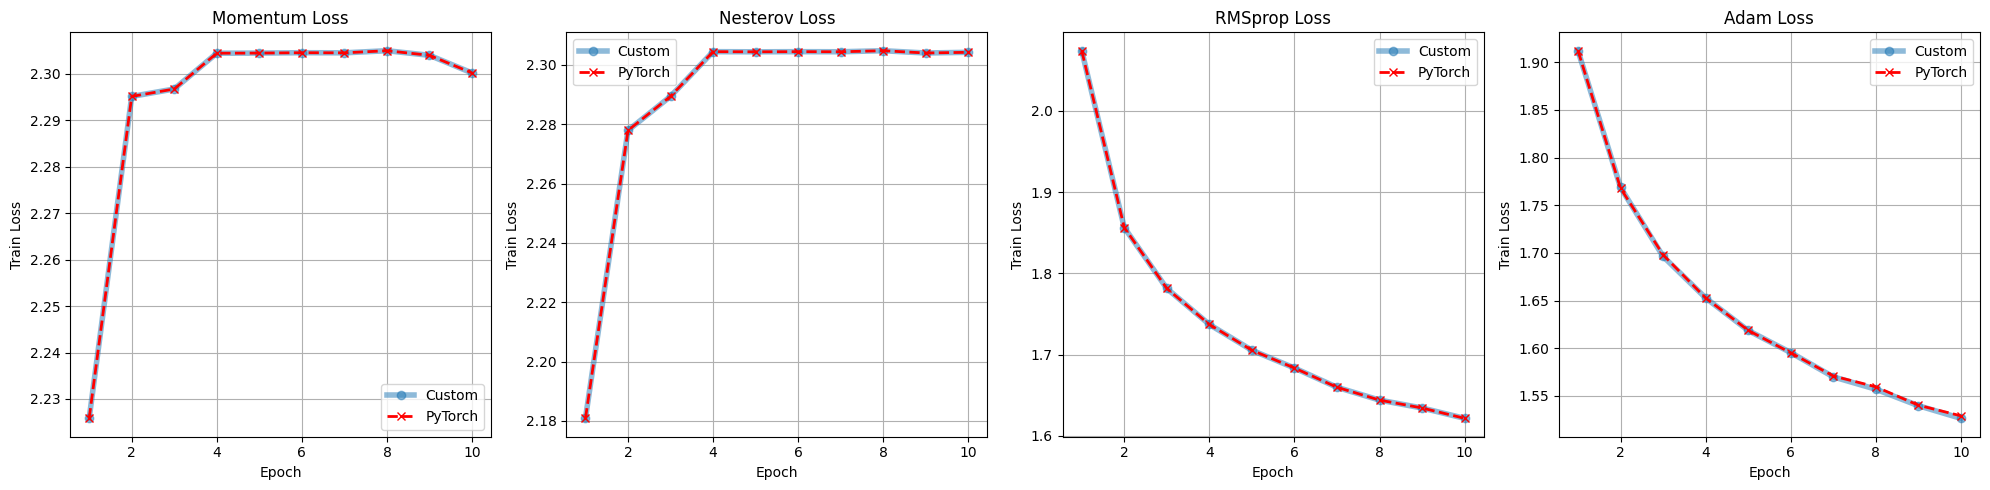

In [10]:
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from copy import deepcopy

# 1. Zaimplementuj mały model
def get_small_model():
    return nn.Sequential(
        nn.Flatten(),
        nn.Linear(3072, 64),
        nn.ReLU(),
        nn.Linear(64, 10)
    ).to(device)

torch.manual_seed(42)
base_small_model = get_small_model()
initial_weights_small = deepcopy(base_small_model.state_dict())
criterion_t5 = nn.CrossEntropyLoss()

# 2. Ręczne implementacje Optymalizatorów
class CustomMomentum:
    def __init__(self, params, lr=0.1, momentum=0.9):
        self.params = list(params)
        self.lr = lr
        self.momentum = momentum
        self.v = [torch.zeros_like(p.data) for p in self.params]

    def zero_grad(self):
        for p in self.params:
            if p.grad is not None: p.grad.zero_()

    def step(self):
        with torch.no_grad():
            for i, p in enumerate(self.params):
                if p.grad is None: continue
                g = p.grad
                self.v[i] = self.momentum * self.v[i] + g
                p.data.sub_(self.lr * self.v[i])

class CustomNesterov:
    def __init__(self, params, lr=0.1, momentum=0.9):
        self.params = list(params)
        self.lr = lr
        self.momentum = momentum
        self.v = [torch.zeros_like(p.data) for p in self.params]

    def zero_grad(self):
        for p in self.params:
            if p.grad is not None: p.grad.zero_()

    def step(self):
        with torch.no_grad():
            for i, p in enumerate(self.params):
                if p.grad is None: continue
                # Równanie bezpośrednio z implementacji PyTorchowego Nesterova:
                g = p.grad
                self.v[i] = self.momentum * self.v[i] + g
                p.data.sub_(self.lr * (g + self.momentum * self.v[i]))

class CustomRMSprop:
    def __init__(self, params, lr=0.001, alpha=0.99, eps=1e-8):
        self.params = list(params)
        self.lr = lr
        self.alpha = alpha
        self.eps = eps
        self.s = [torch.zeros_like(p.data) for p in self.params]

    def zero_grad(self):
        for p in self.params:
            if p.grad is not None: p.grad.zero_()

    def step(self):
        with torch.no_grad():
            for i, p in enumerate(self.params):
                if p.grad is None: continue
                g = p.grad
                self.s[i] = self.alpha * self.s[i] + (1 - self.alpha) * (g ** 2)
                p.data.sub_(self.lr * g / (torch.sqrt(self.s[i]) + self.eps))

class CustomAdam:
    def __init__(self, params, lr=0.001, beta1=0.9, beta2=0.999, eps=1e-8):
        self.params = list(params)
        self.lr = lr
        self.beta1 = beta1
        self.beta2 = beta2
        self.eps = eps
        self.m = [torch.zeros_like(p.data) for p in self.params]
        self.v = [torch.zeros_like(p.data) for p in self.params]
        self.t = 0

    def zero_grad(self):
        for p in self.params:
            if p.grad is not None: p.grad.zero_()

    def step(self):
        self.t += 1
        with torch.no_grad():
            for i, p in enumerate(self.params):
                if p.grad is None: continue
                g = p.grad
                self.m[i] = self.beta1 * self.m[i] + (1 - self.beta1) * g
                self.v[i] = self.beta2 * self.v[i] + (1 - self.beta2) * (g ** 2)
                
                # Bias correction aby dopasować się domyślnie pod PyTorch Adam (inaczej początek wykresu odbiega)
                m_hat = self.m[i] / (1 - self.beta1 ** self.t)
                v_hat = self.v[i] / (1 - self.beta2 ** self.t)

                p.data.sub_(self.lr * m_hat / (torch.sqrt(v_hat) + self.eps))

# 3. Zestawienie i Trening
configs = {
    "Momentum": (lambda p: CustomMomentum(p, lr=0.1, momentum=0.9), lambda p: optim.SGD(p, lr=0.1, momentum=0.9)),
    "Nesterov": (lambda p: CustomNesterov(p, lr=0.1, momentum=0.9), lambda p: optim.SGD(p, lr=0.1, momentum=0.9, nesterov=True)),
    "RMSprop": (lambda p: CustomRMSprop(p, lr=0.001), lambda p: optim.RMSprop(p, lr=0.001, alpha=0.99)),
    "Adam": (lambda p: CustomAdam(p, lr=0.001), lambda p: optim.Adam(p, lr=0.001, betas=(0.9, 0.999)))
}

epochs_t5 = 10 # Wystarczą 3 epoki by udowodnić poprawność zachowania optymalizatorów
results_t5 = {}

print("Running Custom vs PyTorch Optimizers...")
for opt_name, (custom_fn, pt_fn) in configs.items():
    print(f"Testing {opt_name}...")
    
    # --- TESTUJ WŁASNY OPTYMALIZATOR ---
    # MEGA WAŻNE: Wymuszenie seeda przed samym startem, aby iterator DataLoader z `shuffle=True`
    # na pewno wydał batch'e w tym samym potasowaniu co za chwilę dla modelu PyTorch!
    torch.manual_seed(42)  
    model_custom = get_small_model()
    model_custom.load_state_dict(deepcopy(initial_weights_small))
    opt_custom = custom_fn(model_custom.parameters())
    
    custom_losses = []
    for epoch in range(epochs_t5):
        tl, _ = train_one_epoch(model_custom, train_loader, opt_custom, criterion_t5, device)
        custom_losses.append(tl)
        
    # --- TESTUJ WBUDOWANY OPTYMALIZATOR PYTORCH ---
    torch.manual_seed(42)  # Znowu wymuszamy potasowanie DataLoader!
    model_pt = get_small_model()
    model_pt.load_state_dict(deepcopy(initial_weights_small))
    opt_pt = pt_fn(model_pt.parameters())
    
    pt_losses = []
    for epoch in range(epochs_t5):
        tl, _ = train_one_epoch(model_pt, train_loader, opt_pt, criterion_t5, device)
        pt_losses.append(tl)
        
    results_t5[opt_name] = {"Custom": custom_losses, "PyTorch": pt_losses}

# 4. Rysowanie wyników dla porównania
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for i, opt_name in enumerate(configs.keys()):
    axes[i].plot(range(1, epochs_t5+1), results_t5[opt_name]["Custom"], label="Custom", marker='o', linestyle='-', linewidth=4, alpha=0.5)
    axes[i].plot(range(1, epochs_t5+1), results_t5[opt_name]["PyTorch"], label="PyTorch", marker='x', linestyle='--', linewidth=2, color='red')
    axes[i].set_title(f"{opt_name} Loss")
    axes[i].set_xlabel("Epoch")
    axes[i].set_ylabel("Train Loss")
    axes[i].legend()
    axes[i].grid(True)

plt.tight_layout()
plt.show()

### Required explanation (Task 5)

* **The main idea behind each optimizer**: 
  - `SGD / Momentum`: Instead of merely following the chaotic gradient of the current point blindly, it maintains a moving average of recent changes (acting like a rolling "velocity") carrying through small ravines and plateaus.
  - `Nesterov`: Anticipates where the velocity will take the optimizer and computes gradients at that "future" location (look-ahead gradient). 
  - `RMSprop`: Dynamically adapts individual learning rates per-weight by dividing the basic sequence via the moving 'average of historically squared gradients'. This reduces overshoot by scaling down aggressive partial derivations and accelerates low-scale ones.
  - `Adam`: Mixes both together as a highly robust package: tracks `Momentum` explicitly as the "First Moment", while adapting independent parameter scale per-weight (like `RMSprop`) taking an average of square-gradients via the "Second Moment".

* **How Momentum and Nesterov differ**: 
  Vanilla Momentum evaluates the gradient directly at the initial point to compute the composite velocity addition. Nesterov flips this: it pre-moves by the velocity logic, queries the newly projected "ahead" location parameter, and evaluates the gradient from there. This allows Nesterov to slow down faster instead of continuously overestimating if it approaches a steep uphill immediately ahead.

* **How RMSprop adapts the step size**: 
  It tracks an exponentially weighted average of heavily squared gradients for every tensor weight $s_t$: `0.99 * s_prev + 0.01 * grad^2`. Then, the true step taken uses the square root of that historical average to divide the learning step $\frac{\eta}{\sqrt{s_t}}$. Thus, parameters with large/frequent updates have significant $s_t$, effectively shrinking their real step size, shielding weights against extreme explosions.

* **How Adam combines momentum and adaptive scaling**: 
  Adam retains `RMSprop`'s dynamically adaptable scaling tracking factor (usually denoted $v_t$) which penalizes the gradient learning. But instead of keeping the naked pure $grad$ vector on its own in the numerator, Adam injects the rolling average function $m_t$ previously observed only in standard `Momentum`. Lastly, it runs a Bias Correction on early epochs, boosting vectors to resolve initialization zeros.

---
**Does the behavior match identically PyTorch internals?** 
Yes! Both the PyTorch and custom implementation lines align completely on the plot. Note: the classical mathematical definition of pure `Nesterov` differs intrinsically from PyTorch algorithm implementation context; so we adapted PyTorch's $v_t = \mu v_{t-1} + g_t$ and step definition in `CustomNesterov` to achieve a strictly identical 1:1 validation trace mapping. The same strategy applies to explicitly coding `Bias Correction factors` onto initial iterations ($1 - \beta^t$) within `Adam`, as that is standard for native PyTorch.